In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

import os
from pathlib import Path

import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', None)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Георгій\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Георгій\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Георгій\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Георгій\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Loading dataset

In [2]:
isw_path = Path("data/isw/isw_data_v2.json")

isw = pd.read_json(isw_path, convert_dates=["date"]).sort_values("date", ascending=False).reset_index(drop=True)

In [3]:
isw.head()

,date,title,url,text
0,2026-03-10,"Russian Offensive Campaign Assessment, March 1...",https://understandingwar.org/research/russia-u...,Toplines Ukrainian forces advanced 10 to 12 ki...
1,2026-03-09,"Russian Offensive Campaign Assessment, March 9...",https://understandingwar.org/research/russia-u...,Toplines Ukrainian forces are successfully cou...
2,2026-03-08,"Russian Offensive Campaign Assessment, March 8...",https://understandingwar.org/research/russia-u...,Toplines Ukraine will send an unspecified numb...
3,2026-03-07,"Russian Offensive Campaign Assessment, March 7...",https://understandingwar.org/research/russia-u...,Toplines The Russian military command likely h...
4,2026-03-06,"Russian Offensive Campaign Assessment, March 6...",https://understandingwar.org/research/russia-u...,Toplines Russia is reportedly sharing intellig...


# EDA

In [4]:
isw.shape

(2107, 4)

In [5]:
isw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2107 entries, 0 to 2106
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    2107 non-null   datetime64[us]
 1   title   2107 non-null   str           
 2   url     2107 non-null   str           
 3   text    2107 non-null   str           
dtypes: datetime64[us](1), str(3)
memory usage: 51.2 MB


In [6]:
isw.describe()

,date
count,2107
mean,2023-03-24 11:37:47.299478
min,2008-09-13 00:00:00
25%,2022-06-11 12:00:00
50%,2023-10-10 00:00:00
75%,2025-01-18 00:00:00
max,2026-03-10 00:00:00


Data have dates before 2022-02-24. Let's remove them

In [7]:
isw = isw.loc[isw.date >= dt.datetime(2022, 2, 24)]

In [8]:
isw.isna().sum()

date     0
title    0
url      0
text     0
dtype: int64

No missing values

In [9]:
isw.shape

(1723, 4)

In [10]:
isw

,date,title,url,text
0,2026-03-10,"Russian Offensive Campaign Assessment, March 1...",https://understandingwar.org/research/russia-u...,Toplines Ukrainian forces advanced 10 to 12 ki...
1,2026-03-09,"Russian Offensive Campaign Assessment, March 9...",https://understandingwar.org/research/russia-u...,Toplines Ukrainian forces are successfully cou...
2,2026-03-08,"Russian Offensive Campaign Assessment, March 8...",https://understandingwar.org/research/russia-u...,Toplines Ukraine will send an unspecified numb...
3,2026-03-07,"Russian Offensive Campaign Assessment, March 7...",https://understandingwar.org/research/russia-u...,Toplines The Russian military command likely h...
4,2026-03-06,"Russian Offensive Campaign Assessment, March 6...",https://understandingwar.org/research/russia-u...,Toplines Russia is reportedly sharing intellig...
...,...,...,...,...
1718,2022-02-26,Ukraine Conflict Update 8,https://understandingwar.org/research/russia-u...,"Institute for the Study of War, Russia Team IS..."
1719,2022-02-25,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,"Mason Clark, George Barros, and Kateryna Stepa..."
1720,2022-02-25,Ukraine Conflict Update 7,https://understandingwar.org/research/russia-u...,Russia Team February 24 ISW published its most...
1721,2022-02-24,Russia-Ukraine Warning Update: Initial Russian...,https://understandingwar.org/research/russia-u...,"February 24, 3:00 pm EST Russian President Vla..."


## Build histplot by text length

In [11]:
sns.set_style("whitegrid")

In [12]:
isw["text_length"] = isw['text'].apply(len)

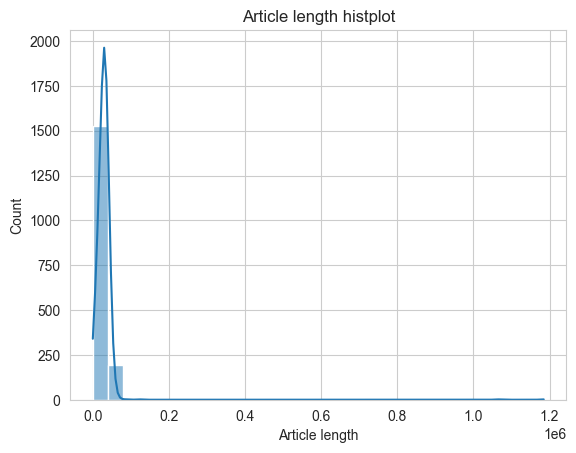

In [13]:
sns.histplot(
    data=isw,
    x="text_length", 
    bins=30,
    kde=True
)


plt.xlabel("Article length")
plt.ylabel("Count")
plt.title("Article length histplot")
plt.show()

Probably we have some outliers. Let's remove 5 most and 5 least longest texts

In [14]:
# remove some outliers for better visualisations
isw.drop(isw.sort_values("text_length").head(5).index.tolist(), inplace=True)
isw.drop(isw.sort_values("text_length").tail(5).index.tolist(), inplace=True)

isw.reset_index(drop=True, inplace=True)

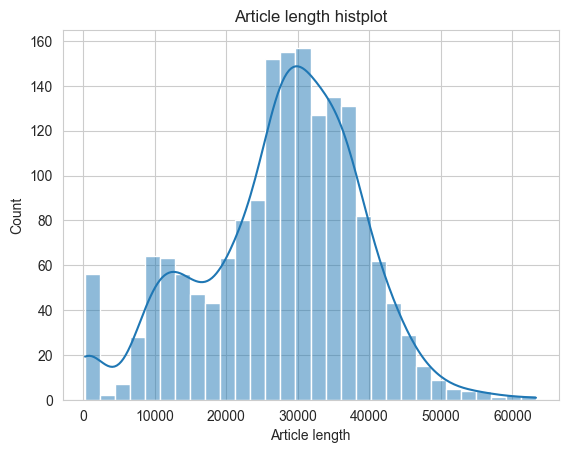

In [15]:
sns.histplot(
    data=isw,
    x="text_length",
    bins=30,
    kde=True
)

plt.xlabel("Article length")
plt.ylabel("Count")
plt.title("Article length histplot")
plt.show()

- Articles text length have bimodal distribution
- Strange peak near 0 length

Look closer to low length articles

In [16]:
with pd.option_context("display.max_colwidth", None):
    print(isw.loc[isw.text_length < 1500, ["url", "text_length"]].sort_values("text_length"))

                                                                                                                          url  \
1176                     https://understandingwar.org/research/russia-ukraine/ukrainian-counteroffensive-makes-slow-progress/   
1179                                  https://understandingwar.org/research/russia-ukraine/russian-units-in-southern-ukraine/   
1301                             https://understandingwar.org/research/russia-ukraine/interactive-time-lapse-one-year-of-war/   
1116                         https://understandingwar.org/research/russia-ukraine/ukraine-makes-tactically-significant-gains/   
1099                      https://understandingwar.org/research/russia-ukraine/critical-moment-for-ukraines-counteroffensive/   
1133                                        https://understandingwar.org/research/russia-ukraine/the-wagner-group-in-belarus/   
530                     https://understandingwar.org/research/russia-ukraine/russias-2024-offensi

In [17]:
isw.loc[isw.text_length < 1500, "text"].sample(10)

893     The ISW Briefing Room Russia Deputy Team Lead ...
1083    The ISW Briefing Room: Episode 17 Putin reappo...
949     The ISW Briefing Room: Episode 29 Russia and U...
1055    The ISW Briefing Room: Episode 20 A popular mi...
433     The ISW Briefing Room: Episode 52 While Russia...
1003    The ISW Briefing Room: Episode 24 Vladimir Put...
1107    The ISW Briefing Room: Episode 13 Kateryna Ste...
1038    The ISW Briefing Room: Episode 21 Karolina Hir...
1688    This op-ed was originally published on The Hil...
925     The ISW Briefing Room: Episode 31 Since Januar...
Name: text, dtype: str

Mostly that is "Briefing Room" articles or comment of polititians or comments on war map updates. Won't remove this data because it could have necessary information.

## Monthly count of articles over time

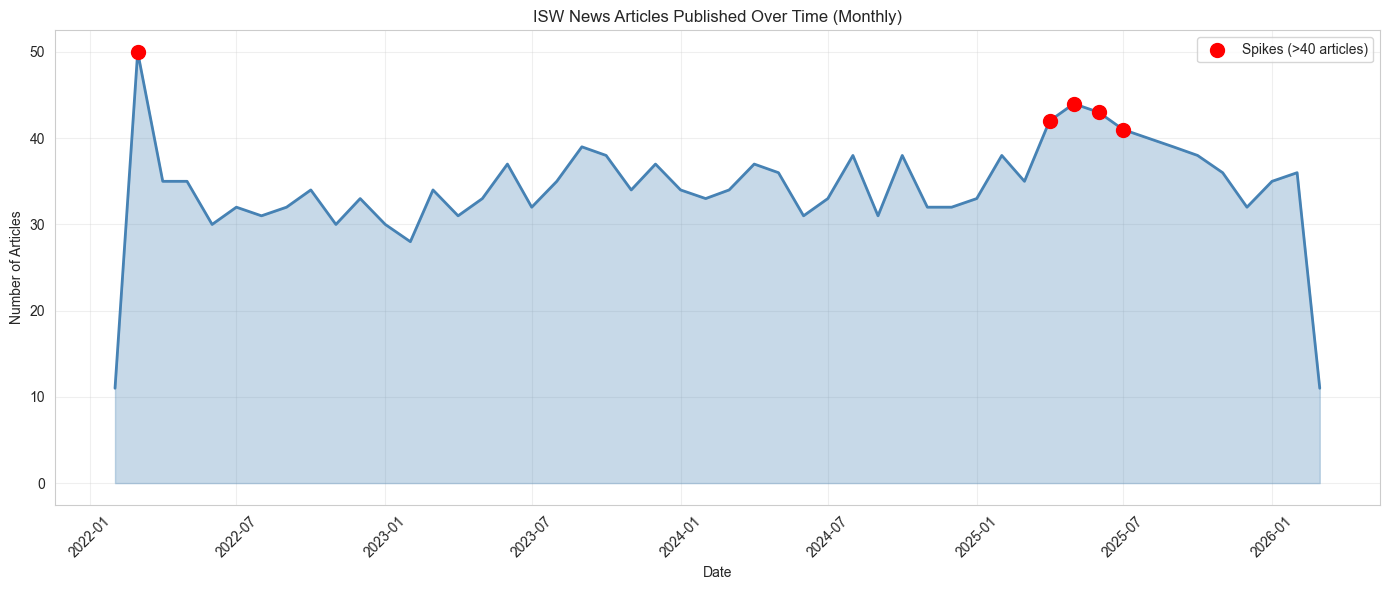

In [18]:
temp = isw.groupby(isw['date'].dt.to_period('M')).size().reset_index(name='count')
temp['date'] = temp['date'].dt.to_timestamp()

plt.figure(figsize=(14, 6))
plt.plot(temp['date'], temp['count'], linewidth=2, color='steelblue')
plt.fill_between(temp['date'], temp['count'], alpha=0.3, color='steelblue')

spike_threshold = temp['count'].quantile(0.9)
spikes = temp[temp['count'] > spike_threshold]
plt.scatter(spikes['date'], spikes['count'], color='red', s=100, zorder=5, label=f'Spikes (>{spike_threshold:.0f} articles)')

plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.title('ISW News Articles Published Over Time (Monthly)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Increasement in number of articles at the start of war
- Increasement in number of articles at first half of 2025

## Check for seasonality

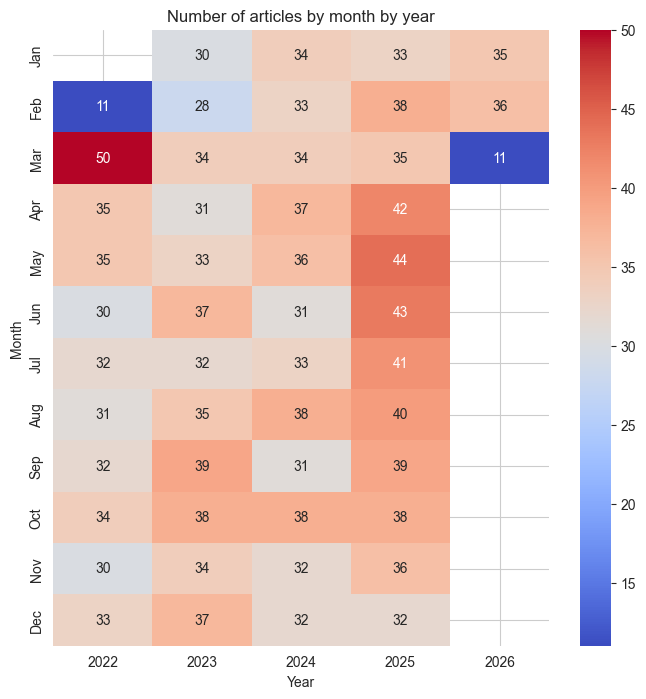

In [19]:
temp = isw[["date"]].copy()
temp["month"] = temp["date"].dt.month
temp["year"] = temp["date"].dt.year

temp = temp.groupby(["year", "month"]).count().reset_index()
temp = temp.pivot(index="month", columns="year", values="date")

month_names = {
 1: 'Jan',
 2: 'Feb',
 3: 'Mar',
 4: 'Apr',
 5: 'May',
 6: 'Jun',
 7: 'Jul',
 8: 'Aug',
 9: 'Sep',
10: 'Oct',
11: 'Nov',
12: 'Dec'
}

temp = temp.rename(index=month_names)

plt.figure(figsize=(8,8))
sns.heatmap(
    data=temp,
    annot=True,
    cmap="coolwarm"
)

plt.title("Number of articles by month by year")
plt.xlabel("Year")
plt.ylabel("Month")
plt.show()

No clear correlation. Increasement in some months probably caused by changes on a war field.

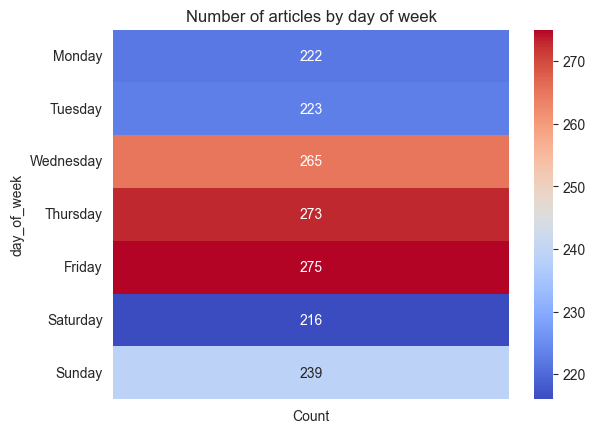

In [20]:
temp = isw[['date']].copy()
temp['day_of_week'] = temp['date'].dt.day_name()

order = {"Monday": 1, "Tuesday": 2, "Wednesday": 3, "Thursday": 4, "Friday": 5, "Saturday": 6, "Sunday": 7}

temp = temp.groupby("day_of_week").count().sort_index(key=lambda s: s.map(order))
temp = temp.rename(columns={"date": "Count"})
sns.heatmap(temp, annot=True, cmap="coolwarm", fmt="")

plt.title("Number of articles by day of week")
plt.show()

More articles at the middle of week

## Vectorizing text

In [21]:
stop_words = {
 'a',
 'about',
 'above',
 'after',
 'again',
 # 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 # "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 # 'couldn',
 # "couldn't",
 'd',
 'did',
 # 'didn',
 # "didn't",
 'do',
 'does',
 # 'doesn',
 # "doesn't",
 'doing',
 'don',
 # "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 # 'hadn',
 # "hadn't",
 'has',
 # 'hasn',
 # "hasn't",
 'have',
 # 'haven',
 # "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 # 'isn',
 # "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 # "mightn't",
 'more',
 'most',
 # 'mustn',
 # "mustn't",
 'my',
 'myself',
 # 'needn',
 # "needn't",
 # 'no',
 # 'nor',
 # 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'only',
 'or',
 'other',
 'our',
 'ours',
 'ourselves',
 'out',
 'over',
 'own',
 're',
 's',
 'same',
 'shan',
 "shan't",
 'she',
 "she'd",
 "she'll",
 "she's",
 'should',
 "should've",
 # 'shouldn',
 # "shouldn't",
 'so',
 'some',
 'such',
 't',
 'than',
 'that',
 "that'll",
 'the',
 'their',
 'theirs',
 'them',
 'themselves',
 'then',
 'there',
 'these',
 'they',
 "they'd",
 "they'll",
 "they're",
 "they've",
 'this',
 'those',
 'through',
 'to',
 'too',
 'under',
 'until',
 'up',
 've',
 'very',
 'was',
 # 'wasn',
 # "wasn't",
 'we',
 "we'd",
 "we'll",
 "we're",
 "we've",
 'were',
 'weren',
 "weren't",
 'what',
 'when',
 'where',
 'which',
 'while',
 'who',
 'whom',
 'whose',
 'why',
 'will',
 'with',
 'won',
 # "won't",
 # 'wouldn',
 # "wouldn't",
 'y',
 'you',
 "you'd",
 "you'll",
 "you're",
 "you've",
 'your',
 'yours',
 'yourself',
 'yourselves',
 "dot"}

In [22]:
lemmatizer = WordNetLemmatizer()

def nltk_preprocess(text):
    tokens = word_tokenize(text.lower())

    tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if t.isalpha() and t not in stop_words
    ]

    return tokens

In [23]:
vectorizer = TfidfVectorizer(
    input="content",
    stop_words=list(stop_words),
    # tokenizer=nltk_preprocess,
    ngram_range=(2,3),
    max_df=0.95,
    min_df=0.05
)

In [24]:
isw["preprocessed_text"] = isw["text"].apply(nltk_preprocess)
isw["preprocessed_text"] = isw["preprocessed_text"].apply(" ".join)

In [25]:
isw.head()

,date,title,url,text,text_length,preprocessed_text
0,2026-03-10,"Russian Offensive Campaign Assessment, March 1...",https://understandingwar.org/research/russia-u...,Toplines Ukrainian forces advanced 10 to 12 ki...,44967,toplines ukrainian force advanced kilometer de...
1,2026-03-09,"Russian Offensive Campaign Assessment, March 9...",https://understandingwar.org/research/russia-u...,Toplines Ukrainian forces are successfully cou...,34619,toplines ukrainian force successfully countera...
2,2026-03-08,"Russian Offensive Campaign Assessment, March 8...",https://understandingwar.org/research/russia-u...,Toplines Ukraine will send an unspecified numb...,22980,toplines ukraine send unspecified number ukrai...
3,2026-03-07,"Russian Offensive Campaign Assessment, March 7...",https://understandingwar.org/research/russia-u...,Toplines The Russian military command likely h...,36040,toplines russian military command likely later...
4,2026-03-06,"Russian Offensive Campaign Assessment, March 6...",https://understandingwar.org/research/russia-u...,Toplines Russia is reportedly sharing intellig...,33528,toplines russia reportedly sharing intelligenc...


In [26]:
isw.loc[0, "preprocessed_text"][:500]

'toplines ukrainian force advanced kilometer deep two separate drive dnipropetrovsk oblast reportedly liberated square kilometer since late january ukrainian separate assault regiment commander captain dmytro filatov regiment operating hulyaipole direction stated march regiment pushed kilometer deep russian position nove zaporizhzhia dobropillya north hulyaipole south oleksandrivka commander ukrainian airborne assault battalion stated march battalion advanced kilometer oleksandrivka direction ukr'

In [27]:
vectorized_text = vectorizer.fit_transform(isw["preprocessed_text"])

In [28]:
vectorized_text.shape

(1713, 6169)

Got 6169 features

In [29]:
feature_names = pd.Series(vectorizer.get_feature_names_out())

In [30]:
feature_names.shape

(6169,)

Look at some created features

In [31]:
feature_names.sample(20)

952                combat capability
6024                      war russia
4656            russian force seized
1722          european international
3215              negotiation russia
2790                         map isw
3433        november ukrainian force
4872                     russian war
285          area forcibly integrate
2098    future political arrangement
3537                 oblast november
724                    bryansk kursk
4572                 russian defense
5731       ukrainian force repelling
3923                 partner isw not
5779                  ukrainian navy
324        area significant activity
4768      russian objective withdraw
727             buffer zone northern
4232                reference source
dtype: str

In [32]:
# Add vectors to DataFrame
isw["vectorized_text"] = vectorized_text.toarray().tolist()

## Most frequent words

C:\Users\Георгій\AppData\Local\Temp\ipykernel_13424\407590534.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=temp, x='frequency', y='word', palette='crest')


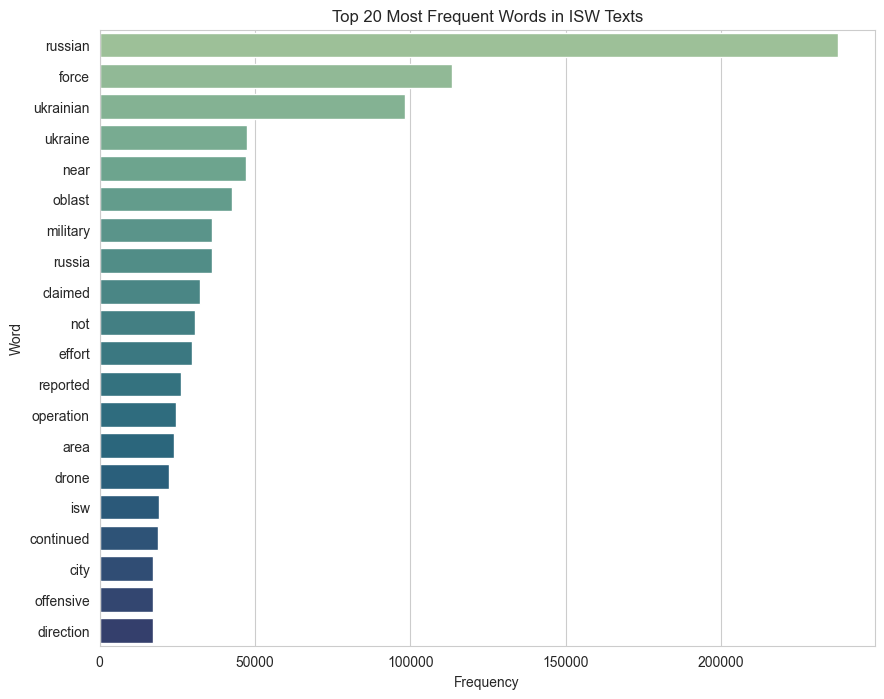

In [33]:
from collections import Counter

all_words = []
for text in isw['text']:
    words = nltk_preprocess(text)
    all_words.extend(words)

word_counts = Counter(all_words)

top_20_words = word_counts.most_common(20)

temp = pd.DataFrame(top_20_words, columns=['word', 'frequency'])

plt.figure(figsize=(10, 8))
sns.barplot(data=temp, x='frequency', y='word', palette='crest')
plt.title('Top 20 Most Frequent Words in ISW Texts')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

## Most/Least frequent n-grams

C:\Users\Георгій\AppData\Local\Temp\ipykernel_13424\271135250.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=temp.sort_values('frequency', ascending=False).head(20),


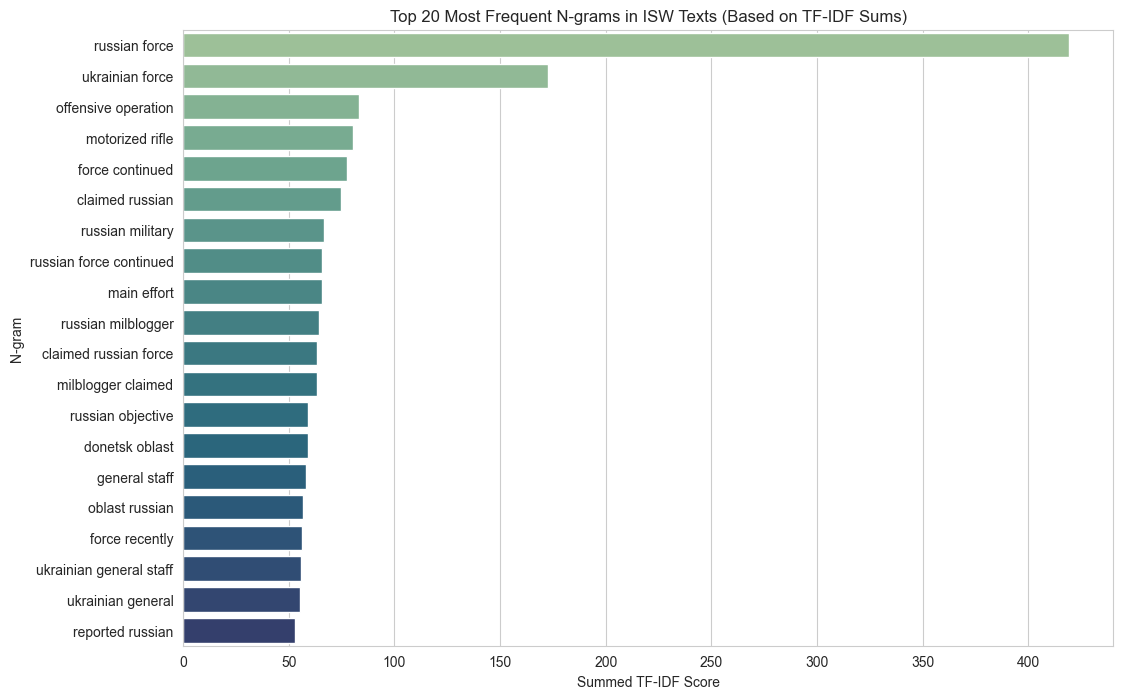

In [34]:
ngram_sums = vectorized_text.sum(axis=0).A1

temp = pd.DataFrame({'ngram': feature_names, 'frequency': ngram_sums})

plt.figure(figsize=(12, 8))
sns.barplot(data=temp.sort_values('frequency', ascending=False).head(20),
            x='frequency', y='ngram', palette="crest")
plt.title('Top 20 Most Frequent N-grams in ISW Texts (Based on TF-IDF Sums)')
plt.xlabel('Summed TF-IDF Score')
plt.ylabel('N-gram')
plt.show()

C:\Users\Георгій\AppData\Local\Temp\ipykernel_13424\4156750635.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=temp.sort_values('frequency', ascending=False).tail(20),


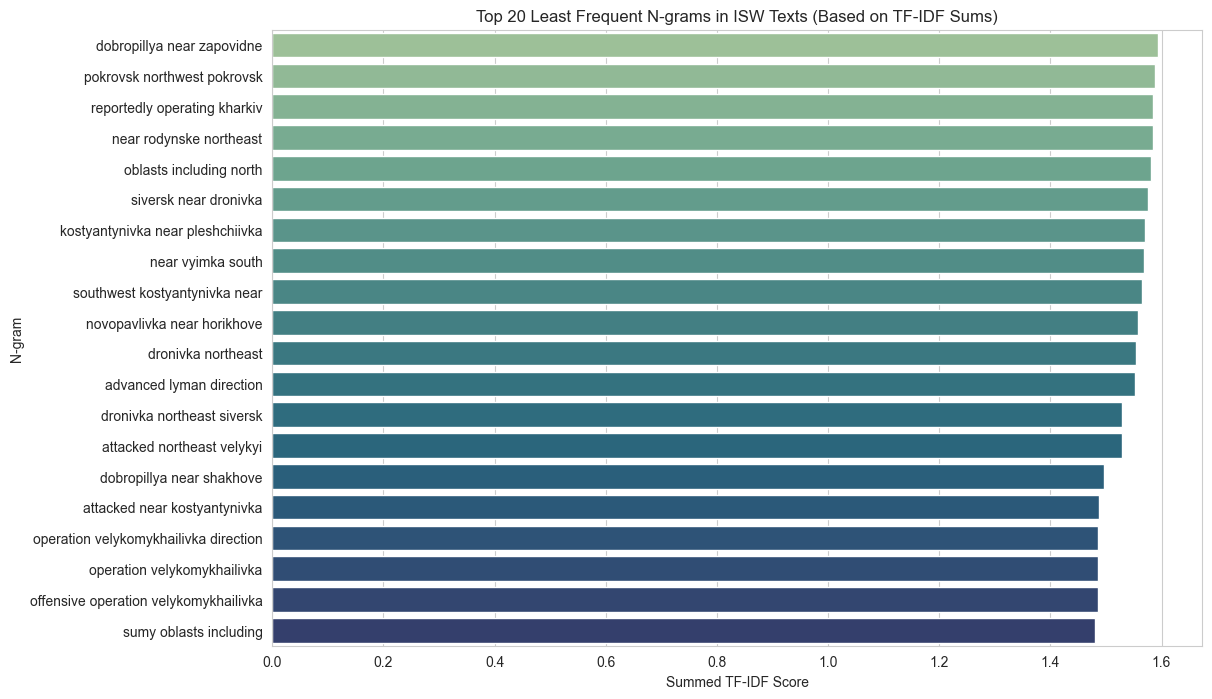

In [35]:
plt.figure(figsize=(12, 8))
sns.barplot(data=temp.sort_values('frequency', ascending=False).tail(20),
            x='frequency', y='ngram', palette='crest')
plt.title('Top 20 Least Frequent N-grams in ISW Texts (Based on TF-IDF Sums)')
plt.xlabel('Summed TF-IDF Score')
plt.ylabel('N-gram')
plt.show()

## Reducing dimesionality of vectors and plotting them

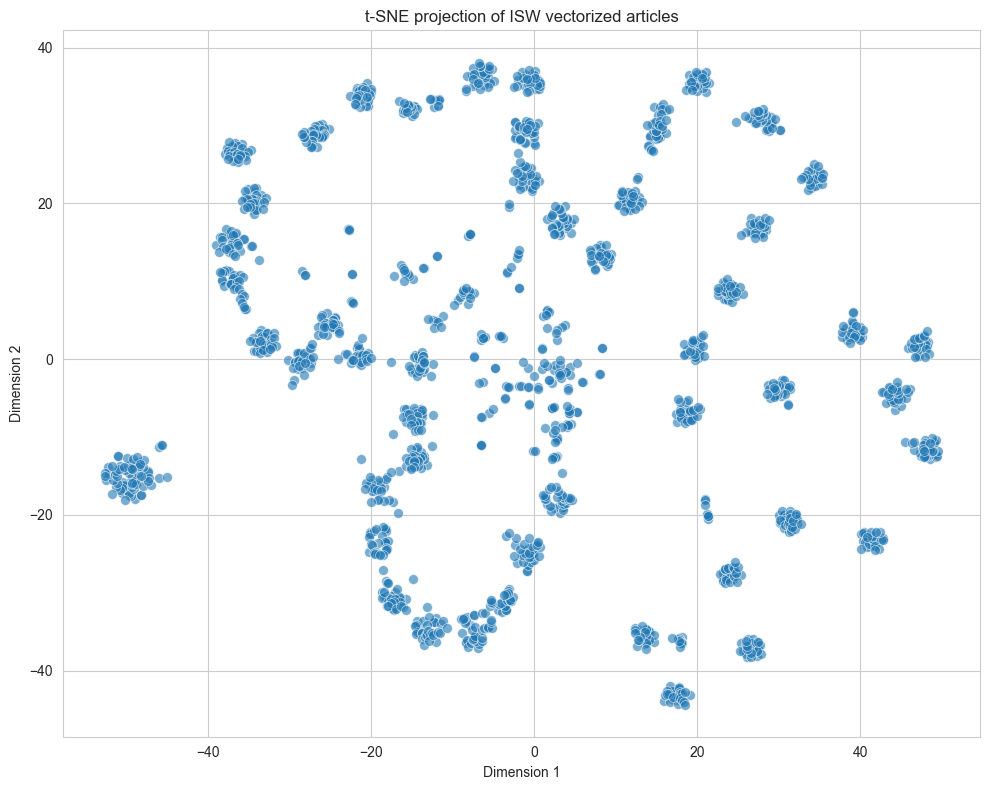

In [36]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2,
            random_state=42,
            perplexity=30,
            max_iter=1000,
            init='pca')
coords = tsne.fit_transform(vectorized_text.toarray())

temp = pd.DataFrame(coords, columns=['x','y'])

plt.figure(figsize=(10, 8))
sns.scatterplot(data=temp, x='x', y='y', s=50, alpha=0.6)
plt.title('t-SNE projection of ISW vectorized articles')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.tight_layout()
plt.show()

- Individual clusters can be clearly seen

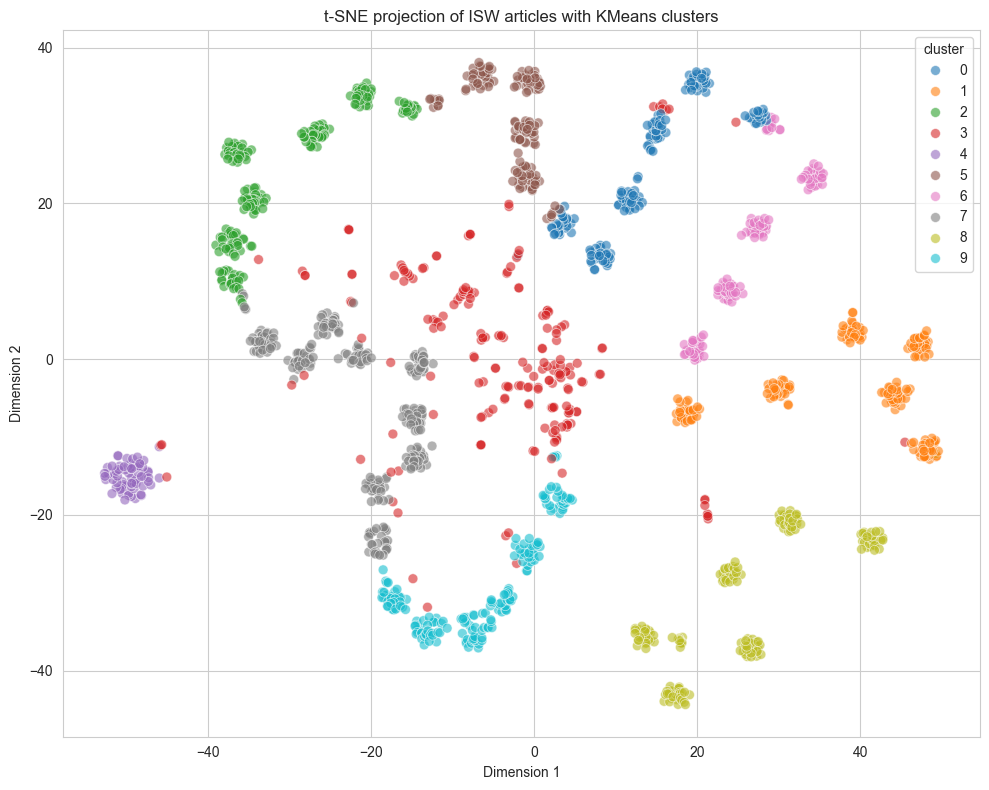

In [37]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=42)
cluster_labels = kmeans.fit_predict(vectorized_text)

temp = pd.DataFrame(coords, columns=['x', 'y'])
temp['cluster'] = cluster_labels

plt.figure(figsize=(10, 8))
sns.scatterplot(data=temp, x='x', y='y',
                hue='cluster', palette='tab10',
                s=50, alpha=0.6, legend='full')
plt.title('t-SNE projection of ISW articles with KMeans clusters')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend(title='cluster')
plt.tight_layout()
plt.show()

## Cluster value counts

C:\Users\Георгій\AppData\Local\Temp\ipykernel_13424\169714662.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


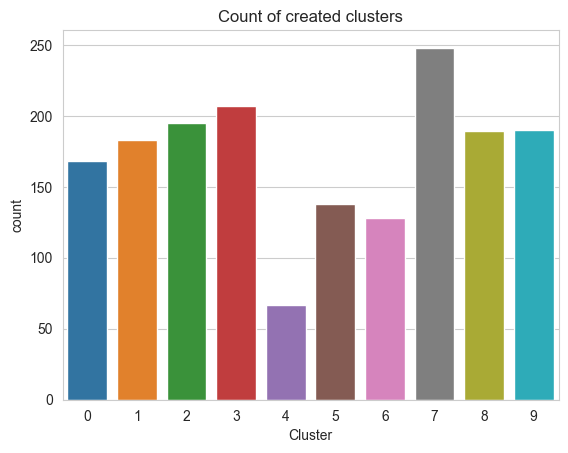

In [38]:
sns.barplot(
    data=pd.Series(cluster_labels).value_counts().sort_index(),
    palette="tab10"
)

plt.title("Count of created clusters")
plt.xlabel("Cluster")
plt.show()

# Data Preparation

## What I already did in EDA

- Filtered data by date >= 2022-02-24
- Added text length column
- Removed 5 most/least longest articles
- Preprocessed text using nltk lemmatizer
- Created vectors that represents text and added column with them
- Created cluster labels

Lets add cluster_labels to isw DataFrame

In [39]:
cluster_labels.shape

(1713,)

In [40]:
isw.shape

(1713, 7)

In [41]:
isw["cluster"] = cluster_labels

In [42]:
isw.head()

,date,title,url,text,text_length,preprocessed_text,vectorized_text,cluster
0,2026-03-10,"Russian Offensive Campaign Assessment, March 1...",https://understandingwar.org/research/russia-u...,Toplines Ukrainian forces advanced 10 to 12 ki...,44967,toplines ukrainian force advanced kilometer de...,"[0.0, 0.0, 0.0, 0.0, 0.008324216475789929, 0.0...",8
1,2026-03-09,"Russian Offensive Campaign Assessment, March 9...",https://understandingwar.org/research/russia-u...,Toplines Ukrainian forces are successfully cou...,34619,toplines ukrainian force successfully countera...,"[0.0, 0.0, 0.0, 0.0, 0.010213080555880546, 0.0...",8
2,2026-03-08,"Russian Offensive Campaign Assessment, March 8...",https://understandingwar.org/research/russia-u...,Toplines Ukraine will send an unspecified numb...,22980,toplines ukraine send unspecified number ukrai...,"[0.0, 0.0, 0.01798845638698764, 0.017988456386...",8
3,2026-03-07,"Russian Offensive Campaign Assessment, March 7...",https://understandingwar.org/research/russia-u...,Toplines The Russian military command likely h...,36040,toplines russian military command likely later...,"[0.0, 0.0, 0.011484386716682187, 0.01148438671...",8
4,2026-03-06,"Russian Offensive Campaign Assessment, March 6...",https://understandingwar.org/research/russia-u...,Toplines Russia is reportedly sharing intellig...,33528,toplines russia reportedly sharing intelligenc...,"[0.0, 0.0, 0.0, 0.0, 0.022699702949531993, 0.0...",8


## Check for duplicates

In [43]:
isw.preprocessed_text.is_unique

False

Data have duplicates

In [44]:
print(f"Number of duplicates: {len(isw) - isw.preprocessed_text.nunique()}")

Number of duplicates: 2


In [45]:
# removing duplicates
isw.drop_duplicates(subset="preprocessed_text",
                    keep="last", # data sorted by date (ascending=False), so "last" would be first mention of article
                    inplace=True,
                   )

In [46]:
isw.shape

(1711, 8)